## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


## **Business Understanding**

### ***The Business Problem***
Your company now sees all the big companies creating original video content and they want to get in on the fun. They have decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

### ***Key Stakeholders***
+ Studio Management
     + Studio Manager
     + Operatios Managers
     + Finance Manager (CFO)
+ Producers and studio crew

### ***Key Objectives/Business questions***
1. Which genres deliver the best financial return? (measured by ROI and median profit) 
2. Which genres do best with an international audience 
3. Which studios perform best and do they align with the top genres

### *Key Metrics of Success according to studio KPIs*


---

## **Data Understanding**
+ For this analysis, I will at the bom.movies_gross.csv.gz dataset for analysis using pandas.
+ For SQL, the database to be used is the im.db, specifically the movie_basics and movie_ratings tables

The main objectives in this initial data understanding is to:
+ Find the column names
+ The shape
+ Any missing values and duplicates
+ Understand the data types 
+ etc

In [116]:
# import the needed libraries and modules:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [117]:
# Make a connection to the database for the sqlite
conn = sqlite3.connect('zippedData/im.db/im.db')

In [118]:
cur = conn.cursor()

In [119]:
bommovies_df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

#### **Data Inspection on: bom.movies_gross.csv.gz**

In [120]:
bommovies_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [121]:
bommovies_df.shape

# From the ouput below, there are 3,387 rows and 5 columns in the dataset of bom.movie_grosss.csv.gz

(3387, 5)

In [122]:
bommovies_df.tail()

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


In [207]:
print("Dataset Information:")
print(bommovies_df.info())

print("Statistical Assesment:")
bommovies_df.describe().T



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB
None
Statistical Assesment:


,count,mean,std,min,25%,50%,75%,max
domestic_gross,3359.0,2.874585e+07,6.698250e+07,100.0,120000.0,1400000.0,27900000.0,936700000.0
foreign_gross,2037.0,7.487281e+07,1.374106e+08,600.0,3700000.0,18700000.0,74900000.0,960500000.0
year,3387.0,2.013958e+03,2.478141e+00,2010.0,2012.0,2014.0,2016.0,2018.0


In [ ]:
print("Dataset Datatypes:")
bommovies_df.dtypes

Dataset Datatypes:


title              object
studio             object
domestic_gross    float64
foreign_gross     float64
year                int64
dtype: object

In [215]:
# Finding Duplicates and Missing Values
print("Duplicates:")
bommovies_df.duplicated().sum()



Duplicates:


0

**There are no duplicates**

In [217]:
# Finding the Missing Values:
print("NaN")
bommovies_df.isna().sum()

NaN


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [130]:
# Missing values in %
def missing(bommovies_df,col):
    missing = (bommovies_df[col].isna().sum()/len(bommovies_df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [220]:
missing(bommovies_df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [132]:
missing(bommovies_df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(bommovies_df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives
None


- studio has missing data of only 5 with a percentage of 0.14. This is insignifanct to warrant dropping the column.
- domestic gross has missing data of 28 with a percentage of 0.83. This is not sufficient enough to have this data dropped.
- foreign gross has missing data. This column has the highest number of NaN the 1350 accounting for the percentage of 39.86. This will not be dropped nevertheless!

**NOTE**
- foreign gross should be float not object 
- year data to be datetime 

In [146]:
# The foreign gross has been converted into the data type of float!
bommovies_df['foreign_gross'] = bommovies_df['foreign_gross'].replace(',','').astype('float')
bommovies_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


### **Movie Data ERD**
![alt text](movie_data_erd.jpeg)


#### **im.db dataset with an a keen interest in the movie_basics and movie_ratings tables**

In [ ]:
queryone = pd.read_sql(""" SELECT name FROM sqlite_master WHERE type = 'table';""",conn)
queryone

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [ ]:
# im.db movie_ratings

ratings = pd.read_sql("""
SELECT * FROM movie_ratings
;
""", conn)

ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [ ]:
ratings.tail()

,movie_id,averagerating,numvotes
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5
73855,tt9894098,6.3,128


In [ ]:
ratings.shape

(73856, 3)

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [ ]:
ratings.describe().T

,count,mean,std,min,25%,50%,75%,max
averagerating,73856.0,6.332729,1.474978,1.0,5.5,6.5,7.4,10.0
numvotes,73856.0,3523.662167,30294.022971,5.0,14.0,49.0,282.0,1841066.0


---

#### **The movie_basics table in the im.db database**

In [ ]:
# im.db movie_basics
basics_querry = pd.read_sql(""" 
SELECT * FROM movie_basics;""",conn)
basics_querry.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [ ]:
basics_querry.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary


In [ ]:
basics_querry.shape

(146144, 6)

In [ ]:
basics_querry.describe().T

,count,mean,std,min,25%,50%,75%,max
start_year,146144.0,2014.621798,2.733583,2010.0,2012.0,2015.0,2017.0,2115.0
runtime_minutes,114405.0,86.187247,166.360590,1.0,70.0,87.0,99.0,51420.0


In [ ]:
# From the output, there are no duplicates
basics_querry.duplicated().sum()

0

In [ ]:
basics_querry.isna().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [ ]:
genre = pd.read_sql(""" SELECT genres FROM movie_basics;""",conn)
genre.head()

,genres
0,"Action,Crime,Drama"
1,"Biography,Drama"
2,Drama
3,"Comedy,Drama"
4,"Comedy,Drama,Fantasy"


In [ ]:
genre1 = pd.read_sql(""" SELECT original_title, genres FROM movie_basics;""",conn)
genre1.head()

,original_title,genres
0,Sunghursh,"Action,Crime,Drama"
1,Ashad Ka Ek Din,"Biography,Drama"
2,The Other Side of the Wind,Drama
3,Sabse Bada Sukh,"Comedy,Drama"
4,La Telenovela Errante,"Comedy,Drama,Fantasy"


In [201]:
genre1.shape

(146144, 2)

In [ ]:
# Your code here - remember to use markdown cells for comments as well!

**Possible Qs:**
- does ratings affect box office success 
- which genre performs well financially - will need to feauture engineer a primary genre column 
- Which studios are most successful, and does that align with the top-performing genres? 
- Out of the films that has a foreign relase, which genre was most successfull amongst international viewers

---

### **1. BUSINESS QUESTION ANALYSIS:**
##### **Which genres do the best with an international audience? Focus on gross revenue.**

---

##### ***Using the tn.movie_budgets.csv.gz over the bom.movies_gross csv.gz to find the which genre does well in the int'l market!***
1. The tn.movie_budget csv dataset is clean, no duplicates and no missing values. This makes it a suitable dataset for finding the which genre beforms well in the international markets based on gross. 
2. Unlike the foreign_gross in the bom.movie_grosss csv dataset, the foreign_gross has missing value of 39% which would jeopardize our analysis.

In [ ]:
tn_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [ ]:
print("DATASET INFORMATION")
print(tn_df.info())

print("DATASET DATA TYPES")
print(tn_df.dtypes)
print(tn_df.shape)
# print(tn_df.duplicated())

print("DUPLICATED ROWS")
print(tn_df.duplicated().sum())

print("MISING VALUES")
print(tn_df.isna().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB
None
DATASET DATA TYPES
id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object
(5782, 6)
DUPLICATED ROWS
0
MISING VALUES
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64


1. **Since the financial figures for production_budget, domestic_gross and worldwide_gross are in objects format, I will convert them to floats formats.**
2. **The release_date is also in object format, this will need to be converted into the time format**

In [ ]:
# Converting the money columns from the object datatype into the float format!
tn_df[['production_budget', 'domestic_gross', 'worldwide_gross']] = tn_df[['production_budget', 'domestic_gross', 'worldwide_gross']].replace(r'[$,]','', regex=True).astype('float')
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [149]:
# Converting the release_date into the date format!
tn_df['release_date'] = pd.to_datetime(tn_df['release_date']).dt.year
tn_df.head(2)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09


In [148]:
# To check if the money columns have been converted into float.
print(tn_df.dtypes)

id                     int64
release_date           int64
movie                 object
production_budget    float64
domestic_gross       float64
worldwide_gross      float64
dtype: object


##### **Merge the tn.movie_budget csv.gz and the column in the im.db called movie_basics.** 
##### **basics_querry and tn_df**

In [165]:
# Now I merge the datasets using an inner join on the primary title and movie. This will give us a combined dataset with both financial and genre information for each movie.
mixed_df = pd.merge(tn_df, basics_querry,
                    left_on="movie",
                    right_on="primary_title",
                    how="inner")

mixed_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09,tt1775309,Avatar,Abatâ,2011,93.0,Horror
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy"
2,3,1970,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,tt6565702,Dark Phoenix,Dark Phoenix,2019,113.0,"Action,Adventure,Sci-Fi"
3,4,1970,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi"
4,7,1970,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi"


In [174]:
# My main focus is the genres column as well as the worldwide_gross because I am trying to understand the which genre did best with the int'l audience based on gross revenue.
# I will therefore try to split the genres column to create a new row for each genre associated with a movie. This will allow us to analyze the data by genre more easily.
genre_df = mixed_df.copy()
genre_df["genre"] = genre_df["genres"].str.split(",")
genre_df = genre_df.explode("genre")
genre_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,genre
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09,tt1775309,Avatar,Abatâ,2011,93.0,Horror,Horror
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Action
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Adventure
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Fantasy
2,3,1970,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,tt6565702,Dark Phoenix,Dark Phoenix,2019,113.0,"Action,Adventure,Sci-Fi",Action


In [ ]:
# Make sure worldwide_gross is numeric first
#genre_df['worldwide_gross'] = pd.to_numeric(genre_df['worldwide_gross'], errors='coerce')

# Total worldwide gross by genre
genre_totals = genre_df.groupby('genre')['worldwide_gross'].sum().sort_values(ascending=False)

# Average worldwide gross by genre (per movie)
genre_avg = genre_df.groupby('genre')['worldwide_gross'].mean().sort_values(ascending=False)

# genre_median = genre_df.groupby('genre')['worldwide_gross'].median().sort_values(ascending=False)

print("TOTAL GENRES")
print(genre_totals.head())

print("GENRE AVG")
print(genre_avg.head(10))

TOTAL GENRES
genre
Adventure    1.383342e+11
Action       1.250989e+11
Drama        1.077621e+11
Comedy       8.614621e+10
Sci-Fi       5.099076e+10
Name: worldwide_gross, dtype: float64
GENRE AVG
genre
Animation    2.997924e+08
Adventure    2.823146e+08
Sci-Fi       2.226671e+08
Musical      2.221234e+08
Fantasy      2.158785e+08
Action       1.761956e+08
Family       1.559764e+08
Comedy       1.023114e+08
Thriller     7.630534e+07
History      7.359891e+07
Name: worldwide_gross, dtype: float64


In [199]:
genre_counts = genre_df.groupby('genre')['worldwide_gross'].count().sort_values(ascending=False)

genre_summary = pd.DataFrame({
    'total_gross': genre_totals,
    'avg_gross': genre_avg,
    'movie_count': genre_counts
}).sort_values('avg_gross', ascending=False)

genre_summary

,total_gross,avg_gross,movie_count
Animation,4.436927e+10,2.997924e+08,148
Adventure,1.383342e+11,2.823146e+08,490
Sci-Fi,5.099076e+10,2.226671e+08,229
Musical,7.774320e+09,2.221234e+08,35
Fantasy,4.360745e+10,2.158785e+08,202
Action,1.250989e+11,1.761956e+08,710
Family,3.181919e+10,1.559764e+08,204
Comedy,8.614621e+10,1.023114e+08,842
Thriller,4.532537e+10,7.630534e+07,594
History,7.065495e+09,7.359891e+07,96


In [226]:
# genre_summary['pct_of_total_gross'] = (genre_summary['total_gross'] / genre_summary['total_gross'].sum()) * 100
# genre_summary

In [230]:
genre_summary['pct_of_total_gross'] = genre_summary['pct_of_total_gross'].round(2)
genre_summary

,total_gross,avg_gross,movie_count,pct_of_total_gross
Animation,4.436927e+10,2.997924e+08,148,5.26
Adventure,1.383342e+11,2.823146e+08,490,16.40
Sci-Fi,5.099076e+10,2.226671e+08,229,6.05
Musical,7.774320e+09,2.221234e+08,35,0.92
Fantasy,4.360745e+10,2.158785e+08,202,5.17
Action,1.250989e+11,1.761956e+08,710,14.83
Family,3.181919e+10,1.559764e+08,204,3.77
Comedy,8.614621e+10,1.023114e+08,842,10.22
Thriller,4.532537e+10,7.630534e+07,594,5.37
History,7.065495e+09,7.359891e+07,96,0.84


##### **Why you want both .sum() and .mean(), not just one:**

+ .sum() tells you which genre generated the most total box office money — but this favors genres that simply appear in more movies (like Drama, which shows up constantly as a secondary genre tag).
+ .mean() tells you which genre performs best per movie — a genre with only 5 movies but huge average gross (e.g., a handful of blockbuster sci-fi films) can beat a genre with 500 mediocre movies.

For a "which genre did best" business question, .mean() is usually the more honest answer, but it's worth showing both and being explicit about which one you're using and why.

##### **Visualization**

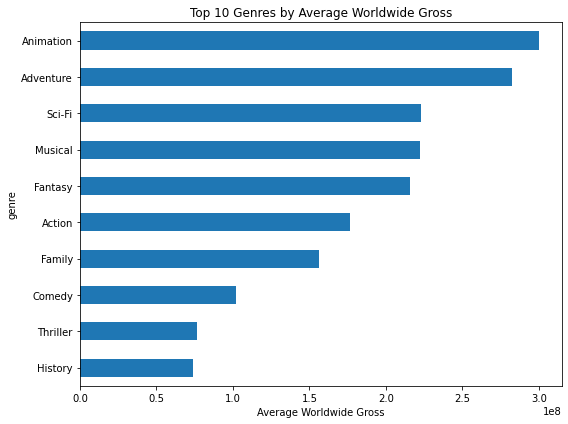

In [193]:
import matplotlib.pyplot as plt

genre_avg.head(10).plot(kind='barh', figsize=(8,6))
plt.xlabel('Average Worldwide Gross')
plt.title('Top 10 Genres by Average Worldwide Gross')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### **FINDINGS AND RECOMMENDATIONS:**

1. ##### **Why USE tn.movie_budgets csv.gz OVER bom.movies_gross csv.gz**
1. The tn.movie_budget csv dataset is clean, no duplicates and no missing values. This makes it a suitable dataset for finding the which genre beforms well in the international markets based on gross. 
2. Unlike the foreign_gross in the bom.movie_grosss csv dataset, the foreign_gross has missing value of 39% which would jeopardize our analysis.

1. ##### **Why you want both .sum() and .mean(), not just one:**

+ .sum() tells you which genre generated the most total box office money — but this favors genres that simply appear in more movies (like Drama, which shows up constantly as a secondary genre tag).
+ .mean() tells you which genre performs best per movie — a genre with only 5 movies but huge average gross (e.g., a handful of blockbuster sci-fi films) can beat a genre with 500 mediocre movies.

For a "which genre did best" business question, .mean() is usually the more honest answer, but it's worth showing both and being explicit about which one you're using and why.


##### **RECOMMENDATIONS**
+ Based on the worldwide gross, the studio should start with making films in the Animation genre.
+ It is also worth noting that movie count number does not translate to higher gross margins. An emphasis should be placed on making quality movies rather making lots of movies which may not be of great quality.
+  The movie making company can go with films in the Adventure and Action genres if they are to consider gross total gross margins only with looking at the average (mean).


##### *BONUS FROM CLAUDE ON THE % ON THE TOTAL GROSS*
A quick heads-up on interpreting this: since a movie can belong to multiple genres (that's the whole reason you exploded the genres column earlier), these percentages will not sum to 100% — each movie's gross gets counted once for every genre it's tagged with. So this tells you "what share of all genre-tagged gross belongs to this genre," not "what share of the actual box office this genre represents" in a strict, non-overlapping sense. Worth mentioning as a caveat if this goes into your write-up.

# **Data Understanding**
- For our analysis, the two most relevant data files we used are:
    - im.db, specifically the movie_basics and movie_ratings tables
    - bom.movie_gross.csv.gz 

### Bom.movie csv 

In [ ]:
df.shape

(3387, 5)

- studio has missing data 
- domestic gross has missing data 
- foreign gross has missing data 
- foreign gross should be float not object 
- year data to be datetime 


In [ ]:
# Missing values %
def missing(df,col):
    missing = (df[col].isna().sum()/len(df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [ ]:
missing(df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives


# **Data Cleaning**

As we saw in our above inspection the following cleaning tasks were to be completed to have a clean data set ready for analysis
1. Bom.movie csv 
    - foreign gross d type needs to be changed from object to float 
    - studio has 0.14% missing data - we can drop those rows 
    - domestic gross has 0.82% if missing data - we can drop those rows 

In [ ]:
df['foreign_gross'].unique()

array(['652000000', '691300000', '664300000', ..., '530000', '256000',
       '30000'], dtype=object)

In [ ]:
# change foreign gross d type 
df['foreign_gross'] = df['foreign_gross'].str.replace(',', '').astype('float')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


In [ ]:
df = df.dropna(subset=['studio'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [ ]:
# Dropping if any rows where BOTH domestic_gross and foreign_gross are missing 
# Without either it is difficult to do any meaningful analysis 
df = df.dropna(subset=['domestic_gross','foreign_gross'], how='all')

In [ ]:
# seems that no such entry exists where both foreign or domestic gross is missing
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [ ]:
df.isna().sum()
# since there is 26 missing values in the domestic gross column
# best option is to drop these missing value rows 

title                0
studio               0
domestic_gross      26
foreign_gross     1349
year                 0
dtype: int64

In [ ]:
df = df.dropna(subset=['domestic_gross'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3356 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3356 non-null   object 
 1   studio          3356 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2007 non-null   float64
 4   year            3356 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 157.3+ KB


In [ ]:
df.describe()

,domestic_gross,foreign_gross,year
count,3.356000e+03,2.007000e+03,3356.000000
mean,2.877149e+07,7.579038e+07,2013.970203
std,6.700694e+07,1.381796e+08,2.479064
min,1.000000e+02,6.000000e+02,2010.000000
25%,1.200000e+05,3.900000e+06,2012.000000
50%,1.400000e+06,1.940000e+07,2014.000000
75%,2.795000e+07,7.595000e+07,2016.000000
max,9.367000e+08,9.605000e+08,2018.000000


In [ ]:
df[df.duplicated(subset=['title'])]

,title,studio,domestic_gross,foreign_gross,year
3045,Bluebeard,WGUSA,43100.0,NaN,2017


<AxesSubplot:xlabel='domestic_gross'>

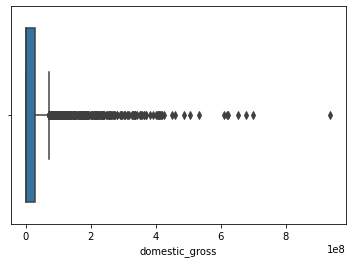

In [ ]:
sns.boxplot(x=df['domestic_gross'])

<AxesSubplot:xlabel='domestic_gross', ylabel='Count'>

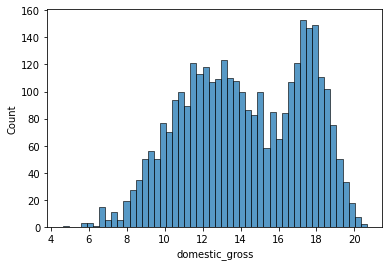

In [ ]:
sns.histplot(np.log1p(df['domestic_gross']), bins=50)

In [ ]:
Q1 = df['domestic_gross'].quantile(0.25)
Q3 = df['domestic_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['domestic_gross'] < lower) | (df['domestic_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 406


In [ ]:
Q1 = df['foreign_gross'].quantile(0.25)
Q3 = df['foreign_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['foreign_gross'] < lower) | (df['foreign_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 256


**Note**: Although domestic gross and foreign gross both have outliers in our dataset we made the decision to retain them. This is because financial data like box office gross is meaningful data and is quite realistic

2. Movie ERD

In [ ]:
query = pd.read_sql("""
SELECT name FROM sqlite_master WHERE type='table';
""", conn)
query

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [ ]:
movie_basics = pd.read_sql("""SELECT * FROM movie_basics;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

In [ ]:
movie_ratings = pd.read_sql("""
SELECT * FROM movie_ratings;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

# **Exploratory Data Analysis**

## Business Question: Which Genres Perform Best Financially (Domestic audience)
 - In order to explore this Business Q, the movie_basics table needs to be merged with the bom.movie csv 
 - Since IMDB contains a much broader set of films than what's tracked at the box office, we merged the two datasets on both **title** and **release year** to ensure we matched the correct 
version of each film (avoiding false matches between unrelated films that happen 
to share a title).

In [ ]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [ ]:
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [ ]:
# merge both tables 

movie_basics_df = pd.read_sql("""
SELECT * FROM movie_basics;""", conn)

In [ ]:
merged_df = pd.merge(
    movie_basics_df, 
    df,
    left_on='primary_title',
    right_on='title',
    how="inner")

In [ ]:
merged_df.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,Relbig.,1100000.0,NaN,2016
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,IFC,744000.0,8000000.0,2012
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
5,tt5389486,On the Road,On the Road,2015,39.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
6,tt5647250,On the Road,On the Road,2016,121.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
7,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",The Secret Life of Walter Mitty,Fox,58200000.0,129900000.0,2013
8,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",A Walk Among the Tombstones,Uni.,26300000.0,26900000.0,2014
9,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",Jurassic World,Uni.,652300000.0,1019.4,2015


In [ ]:
merged_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
3336,tt8404272,How Long Will I Love U,Chao shi kong tong ju,2018,101.0,Romance,How Long Will I Love U,WGUSA,747000.0,82100000.0,2018
3337,tt8427036,Helicopter Eela,Helicopter Eela,2018,135.0,Drama,Helicopter Eela,Eros,72000.0,NaN,2018
3338,tt8851262,Spring Fever,Spring Fever,2019,NaN,"Comedy,Horror",Spring Fever,Strand,10800.0,150000.0,2010
3339,tt9078374,Last Letter,"Ni hao, Zhihua",2018,114.0,"Drama,Romance",Last Letter,CL,181000.0,NaN,2018
3340,tt9151704,Burn the Stage: The Movie,Burn the Stage: The Movie,2018,84.0,"Documentary,Music",Burn the Stage: The Movie,Trafalgar,4200000.0,16100000.0,2018


In [ ]:
merged_df.duplicated().sum()

0

In [ ]:
merge = pd.merge(movie_basics_df, df[['title','domestic_gross', 'foreign_gross']],
                 left_on='primary_title',
                 right_on='title',
                 how="inner")

merge.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,744000.0,8000000.0
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,744000.0,8000000.0
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,744000.0,8000000.0
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,744000.0,8000000.0


In [ ]:
merge.isna().sum()

movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes     167
genres               40
title                 0
domestic_gross        0
foreign_gross      1322
dtype: int64

Note - ran into unexpected duplication and Nan values when merging. Next strategy employed is to change the column_name in the csv to match the column name on the movie_basics table to merge easily

In [ ]:
df_q_1 = df.rename(columns={'title': 'primary_title', 'year': 'start_year'})

merge_1 = pd.merge(movie_basics_df, 
                    df_q_1[['primary_title', 'start_year', 'domestic_gross', 'foreign_gross']],
                    on=['primary_title', 'start_year'],
                    how="inner")


In [ ]:
merge_1.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000.0,8000000.0
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000.0,129900000.0
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000.0,26900000.0
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000.0,1019.4
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000.0,10800000.0
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000.0,NaN
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000.0,10500000.0
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000.0,391000000.0
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000.0,211100000.0


In [ ]:
merge_1.isna().sum()

movie_id             0
primary_title        0
original_title       0
start_year           0
runtime_minutes     10
genres               2
domestic_gross       0
foreign_gross      595
dtype: int64

In [ ]:
merge_1['primary_title'].value_counts().head(30)

The Wall             3
Truth or Dare        2
Colette              2
Sisters              2
Spotlight            2
Extraction           2
Denial               2
Burlesque            2
Abduction            2
True Story           2
The Journey          2
The Bounty Hunter    2
The Guardians        2
The Negotiation      2
Stronger             2
Three                2
The Forest           2
Cyrus                2
The Bay              2
Dancer               2
Leap Year            2
The Walk             2
The Call             2
Gone                 2
The Night Before     2
Lights Out           2
The Other Side       2
A Better Life        2
Sleepless            2
Big Eyes             2
Name: primary_title, dtype: int64

In [ ]:
print(len(movie_basics_df), len(merge_1))

146144 1863


In [ ]:
print(len(df))

3356


### **Handling Multiple Genres per Film**

Many films in this dataset are tagged with more than one genre (e.g. "Action, 
Crime, Drama"). Since IMDB does not confirm that genres are listed in order of 
importance, we chose the **first listed genre** for each film as a simplifying 
label for our primary analysis, rather than assuming it represents the film's 
single "true" genre. This is a methodology choice, not a confirmed 
classification from IMDB — we revisit this assumption later with a cross-check 
using an alternate method.

In [ ]:
merge_1['primary_genre'] = merge_1['genres'].str.split(',').str[0]

In [ ]:
merge_1.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
domestic_gross     float64
foreign_gross      float64
primary_genre       object
dtype: object

In [ ]:
merge_1.head(10)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross,primary_genre
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000.0,NaN,Action
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000.0,8000000.0,Adventure
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000.0,129900000.0,Adventure
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000.0,26900000.0,Action
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000.0,1019.4,Action
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000.0,10800000.0,Comedy
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000.0,NaN,Crime
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000.0,10500000.0,Comedy
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000.0,391000000.0,Adventure
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000.0,211100000.0,Action


In [ ]:
merge_1['primary_genre'].value_counts()

Action         521
Comedy         396
Drama          333
Biography      168
Adventure      166
Documentary     81
Crime           79
Horror          67
Animation       18
Fantasy          9
Thriller         8
Romance          7
Mystery          5
Music            2
Sci-Fi           1
Name: primary_genre, dtype: int64

### Ensuring Reliable Comparisons Across Genres

Some genres in our merged dataset are represented by only a handful of films. 
Averaging financial performance across a very small sample can be misleading — 
a single unusually successful or unsuccessful film can swing the average and 
create a false impression of how that genre performs overall.

To keep our comparisons meaningful, we only included the top 6 genres in our merged dataset.

In [ ]:
merge_1['start_year'].describe()

count    1863.000000
mean     2014.011272
std         2.514700
min      2010.000000
25%      2012.000000
50%      2014.000000
75%      2016.000000
max      2018.000000
Name: start_year, dtype: float64

In [ ]:
financial = merge_1.groupby('primary_genre')['domestic_gross'].mean().sort_values(ascending=False)

financial 

primary_genre
Adventure      8.962618e+07
Action         6.965484e+07
Mystery        6.705660e+07
Animation      5.006581e+07
Horror         3.969576e+07
Comedy         2.742875e+07
Biography      2.635948e+07
Crime          2.099816e+07
Drama          1.840538e+07
Romance        9.264714e+06
Thriller       6.950650e+06
Documentary    6.702051e+06
Fantasy        4.544667e+06
Music          1.836000e+06
Sci-Fi         7.800000e+04
Name: domestic_gross, dtype: float64

In [ ]:
financial.head(10)

primary_genre
Adventure    8.962618e+07
Action       6.965484e+07
Mystery      6.705660e+07
Animation    5.006581e+07
Horror       3.969576e+07
Comedy       2.742875e+07
Biography    2.635948e+07
Crime        2.099816e+07
Drama        1.840538e+07
Romance      9.264714e+06
Name: domestic_gross, dtype: float64

In [ ]:
financial_millions = (financial / 1_000_000).round(1)
financial_millions

primary_genre
Adventure      89.6
Action         69.7
Mystery        67.1
Animation      50.1
Horror         39.7
Comedy         27.4
Biography      26.4
Crime          21.0
Drama          18.4
Romance         9.3
Thriller        7.0
Documentary     6.7
Fantasy         4.5
Music           1.8
Sci-Fi          0.1
Name: domestic_gross, dtype: float64

In [ ]:
top6 = financial_millions.head(6)

### **Visualization**

We converted average domestic gross from raw dollar figures into millions 
(e.g. $89,626,180 → $89.6M) to make the chart easier to read for a non-technical 
audience. The chart below shows the top 6 genres by average domestic gross, 
based only on genres with a reliable sample size of films.

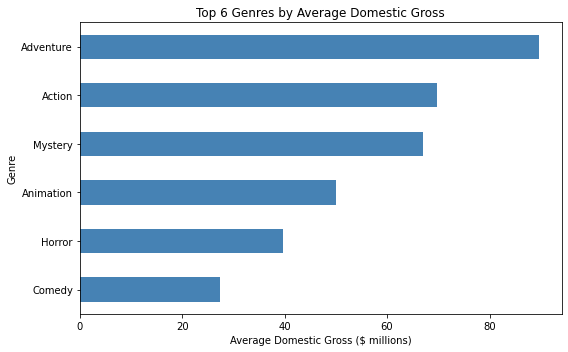

In [ ]:
plt.figure(figsize=(8, 5))
top6.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 6 Genres by Average Domestic Gross')
plt.xlabel('Average Domestic Gross ($ millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**What this chart shows**: Average domestic box office earnings for the top 6 genres, in millions of dollars. Adventure leads at ~$89.6M per film, followed by Action at ~$69.7M. We used averages (not totals) and only included genres with at least 5 films, so the comparison is fair.

In [ ]:
recent = merge_1[merge_1['start_year'] >= 2014]

recent_genre_counts = recent['primary_genre'].value_counts()
recent_reliable_genres = recent_genre_counts[recent_genre_counts >= 5].index

recent_financial = recent[recent['primary_genre'].isin(recent_reliable_genres)] \
    .groupby('primary_genre')['domestic_gross'].mean().sort_values(ascending=False)

recent_financial_millions = (recent_financial / 1_000_000).round(1)
recent_financial_millions.head(6)

primary_genre
Adventure    82.7
Action       74.5
Horror       44.3
Animation    35.0
Biography    25.4
Comedy       24.3
Name: domestic_gross, dtype: float64

In [ ]:
comparison = pd.DataFrame({
    'all_years': financial_millions,
    'recent_years': recent_financial_millions
})
comparison.head(10)

,all_years,recent_years
Action,69.7,74.5
Adventure,89.6,82.7
Animation,50.1,35.0
Biography,26.4,25.4
Comedy,27.4,24.3
Crime,21.0,18.4
Documentary,6.7,6.8
Drama,18.4,17.9
Fantasy,4.5,0.5
Horror,39.7,44.3


**All years vs. recent years**: We checked whether our genre rankings held up using only films from 2014 onward, not just the full 2010–2018 dataset. Adventure and Action stayed on top in both, confirming the finding is stable. Horror trended up in recent years, while Animation trended down.

### Summary 

Based on average domestic gross per film, Adventure and Action are the two strongest-performing genres. Since a decade-long average can be skewed by outdated trends, we re-ran the analysis using only films released from 2014 onward. The results held up with Adventure and Action remained the top two genres, with comparable average gross figures (82.7M and
74.5M respectively), giving us confidence this is a stable pattern rather than a temporary spike driven by older data.
Two notable shifts worth flagging:
- Horror's average gross increased in recent years (44.3M), suggesting growing commercial momentum.
- Animation's average declined (35.0M), suggesting its appetite among audiences may be declining

### Cross-Check: Comparing Against an "Exploded" Genre Approach

As an alternative to using each film's first listed genre, we also tested an 
approach where films with multiple genres are counted under **all** of their 
listed genres (an "exploded" genre column). This avoids the assumption that 
the first genre listed is more important than the others, though it means a 
film's revenue is counted once for each genre it's tagged with, rather than 
just once overall.

In [ ]:
merge_1_exploded = merge_1.copy()
merge_1_exploded['genres'] = merge_1_exploded['genres'].str.split(',')
merge_1_exploded = merge_1_exploded.explode('genres')

In [ ]:
exploded_genre_counts = merge_1_exploded['genres'].value_counts()
exploded_reliable_genres = exploded_genre_counts[exploded_genre_counts >= 5].index

merge_1_exploded_reliable = merge_1_exploded[merge_1_exploded['genres'].isin(exploded_reliable_genres)]

In [ ]:
exploded_financial = merge_1_exploded_reliable.groupby('genres')['domestic_gross'].mean().sort_values(ascending=False)
exploded_financial_millions = (exploded_financial / 1_000_000).round(1)
exploded_financial_millions.head(6)

genres
Sci-Fi       132.7
Animation    115.4
Adventure    112.1
Action        69.7
Fantasy       67.2
Family        60.7
Name: domestic_gross, dtype: float64

**Prioritize Animation, Adventure and Sci-Fi**

These three genres perform strongly on both profitability and ROI:

Animation – highest median profit ($194M) and very high ROI (198%).

Adventure – second-highest median profit ($128M) and strong ROI (162%).

Sci-Fi – third-highest median profit ($116M) and ROI (168%).

Recommendation: These should be the primary genres for investment because they combine strong returns with high absolute profits.

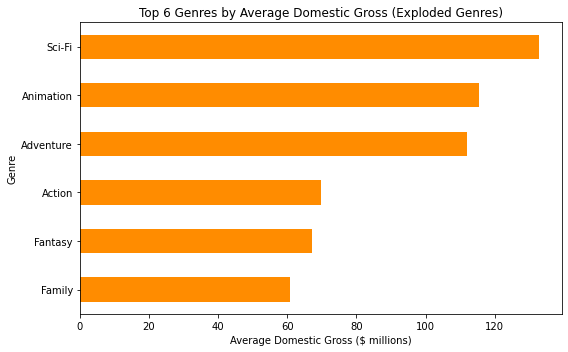

In [ ]:
top6_exploded = exploded_financial_millions.head(6)

plt.figure(figsize=(8, 5))
top6_exploded.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 6 Genres by Average Domestic Gross (Exploded Genres)')
plt.xlabel('Average Domestic Gross ($ millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Result of Cross-Check
**Based on the visualizations, the following are the best recommendations;**

**Prioritize Animation, Adventure and Sci-Fi**

These three genres perform strongly on both profitability and ROI:

Animation – highest median profit ($194M) and very high ROI (198%).

Adventure – second-highest median profit ($128M) and strong ROI (162%).

Sci-Fi – third-highest median profit ($116M) and ROI (168%).

Recommendation: These should be the primary genres for investment because they combine strong returns with high absolute profits.

**Consider Mystery for high-return, lower-risk investments**

Mystery has the highest median ROI (~208%), meaning it generates the strongest return relative to the amount invested. However, its median profit (~$32M) is much lower than Animation, Adventure and Sci-Fi.

Recommendation: Invest in Mystery when the goal is capital efficiency/ROI, rather than maximizing total dollar profit.

**Be very careful when investing in Drama, Sport and Documentary**

These genres appear at the bottom of the profitability chart:

Documentary – extremely low median profit and ROI.

Drama – low median profit and relatively low ROI.

Sport – low median profit and ROI.

Recommendation: Avoid large investments in these genres unless there are specific factors—such as a strong franchise, famous cast, low production budget, or clear target audience—that justify the investment.

**EDA Summary**


**1. I first examined the structure of the dataset**

Checked the columns, data types, number of records, and missing values.
Identified the important variables for analyzing movie performance, such as genre, budget, revenue, profit, ROI, and movie count.

Unlike our earlier median/recent-years checks, this comparison revealed a 
meaningful difference. Under the exploded-genre approach, **Sci-Fi, Animation, 
and Fantasy** rise sharply in the rankings, genres that were underrepresented 
or excluded entirely under the first-listed-genre method, since they often 
appear as a *secondary* genre tag on major franchise films (e.g. an 
action-adventure movie also tagged Sci-Fi).

# **Recommendation**
Only **Adventure and Action** remain in the top tier under both methods, making 
them the most consistently strong recommendation regardless of how multi-genre 
films are handled. Genres like Sci-Fi, Animation, and Fantasy show strong 
potential too, but their ranking is more sensitive to methodology, and should 
be treated as a secondary, less certain finding rather than as confident as 
our Adventure/Action recommendation.


---


# KEVIN N

## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


In [ ]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [ ]:
conn = sqlite3.connect('zippedData/im.db')

In [ ]:
cur = conn.cursor()

In [ ]:
df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

# **Data Understanding**
- For our analysis, the two most relevant data files we used are:
    - im.db, specifically the movie_basics and movie_ratings tables
    - bom.movie_gross.csv.gz 

In [ ]:
# bom.movie_gross

In [ ]:
df.shape

(3387, 5)

In [ ]:
df.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [ ]:
df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


- studio has missing data 
- domestic gross has missing data 
- foreign gross has missing data 
- foreign gross should be float not object 
- year data to be datetime 


In [ ]:
df.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [ ]:
# Missing values %
def missing(df,col):
    missing = (df[col].isna().sum()/len(df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [ ]:
missing(df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives


In [ ]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


### Movie Data ERD 
![alt text](movie_data_erd.jpeg)


In [ ]:
# im.db movie_basics 
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [ ]:
# im.db movie_ratings

query_2 = pd.read_sql("""
SELECT * FROM movie_ratings 
LIMIT 5;
""", conn)

query_2

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [ ]:
# Your code here - remember to use markdown cells for comments as well!

possible Qs:
- does ratings affect box office success 
- which genre performs well financially - will need to feauture engineer a primary genre column 
- Which studios are most successful, and does that align with the top-performing genres? 
- Out of the films that has a foreign relase, which genre was most successfull amongst international viewers





**Business question analysis:**

**1. Which genres deliver the best financial return, measured by ROI and median profit?**

In [ ]:
# 1. We load in our movie budget data from the im.db database and check the first 5 rows of the data.

budgets_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
budgets_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


---


In [ ]:
# 2. Then we check the data to know how to clean it up. We check the info, missing values and duplicates.

print("Dataset Information")
budgets_df.info()

print("\nMissing Values")
print(budgets_df.isna().sum())

print("\nDuplicate Rows")
print(budgets_df.duplicated().sum())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB

Missing Values
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

Duplicate Rows
0


In [ ]:
# 3.Since the money columns are in float format, we can go ahead and calculate the profit column by subtracting the production_budget from the worldwide_gross. We will create a new column called profit to store the results of this calculation.

budgets_df["profit"] = budgets_df["worldwide_gross"] - budgets_df["production_budget"]

#We then calculate the ROI (Return on Investment) by dividing the profit by the production_budget and multiplying by 100 to get a percentage. We will create a new column called ROI to store the results of this calculation.
budgets_df["ROI"] = (budgets_df["profit"] / budgets_df["production_budget"]) * 100

#Then view the results of the calculations by checking the first 5 rows of the data.
budgets_df[["movie","production_budget", "worldwide_gross", "profit", "ROI"]].head()

,movie,production_budget,worldwide_gross,profit,ROI
0,Avatar,425000000.0,2.776345e+09,2.351345e+09,553.257713
1,Pirates of the Caribbean: On Stranger Tides,410600000.0,1.045664e+09,6.350639e+08,154.667286
2,Dark Phoenix,350000000.0,1.497624e+08,-2.002376e+08,-57.210757
3,Avengers: Age of Ultron,330600000.0,1.403014e+09,1.072414e+09,324.384139
4,Star Wars Ep. VIII: The Last Jedi,317000000.0,1.316722e+09,9.997217e+08,315.369636


In [ ]:
# 4. Next we get the genres from the IMDb database
conn = sqlite3.connect('zippedData/im.db')

movie_basics = pd.read_sql("""
SELECT
    primary_title, start_year, genres
FROM movie_basics
WHERE genres IS NOT NULL
""", conn)

movie_basics.head()

,primary_title,start_year,genres
0,Sunghursh,2013,"Action,Crime,Drama"
1,One Day Before the Rainy Season,2019,"Biography,Drama"
2,The Other Side of the Wind,2018,Drama
3,Sabse Bada Sukh,2018,"Comedy,Drama"
4,The Wandering Soap Opera,2017,"Comedy,Drama,Fantasy"


In [ ]:
#5. We should then create a release year in the budget data inorder to match the movies more accurately
budgets_df["release_year"] = pd.to_datetime(budgets_df["release_date"]).dt.year

# 6. Now I merge the datasets using an inner join on the movie title and release year. This will give us a combined dataset with both financial and genre information for each movie.
movies_df = budgets_df.merge(
    movie_basics,left_on=["movie","release_year"],right_on=["primary_title","start_year"],how="inner"
)

movies_df.shape
movies_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,ROI,release_year,primary_title,start_year,genres
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy"
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi"
2,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,324.384139,2015,Avengers: Age of Ultron,2015,"Action,Adventure,Sci-Fi"
3,7,2018-04-27,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,1.748134e+09,582.711400,2018,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi"
4,9,2017-11-17,Justice League,300000000.0,229024295.0,6.559452e+08,3.559452e+08,118.648403,2017,Justice League,2017,"Action,Adventure,Fantasy"


In [ ]:
#7. Now we could explode the genres column to create a new row for each genre associated with a movie. This will allow us to analyze the data by genre more easily.
genre_df = movies_df.copy()

genre_df["genre"] = genre_df["genres"].str.split(",")

genre_df = genre_df.explode("genre")

genre_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,ROI,release_year,primary_title,start_year,genres,genre
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Action
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Adventure
0,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,635063875.0,154.667286,2011,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",Fantasy
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-200237650.0,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi",Action
1,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-200237650.0,-57.210757,2019,Dark Phoenix,2019,"Action,Adventure,Sci-Fi",Adventure


In [ ]:
#8. Now we can calculate the financial performance by genre by grouping the data by genre and calculating the mean of the profit and ROI columns.
genre_performance = (
    genre_df
    .groupby("genre")
    .agg(
        median_ROI=("ROI", "median"),
        median_profit=("profit", "median"),
        movie_count=("movie", "count")
    )
    .sort_values("median_ROI", ascending=False)
)

genre_performance.style.format({
    "median_ROI": "{:,.2f}%",
    "median_profit": "${:,.2f}",
    "movie_count": "{:,}"
})

,median_ROI,median_profit,movie_count
genre,,,
Mystery,207.57%,"$32,054,270.00",128
Animation,198.19%,"$194,139,928.50",102
Sci-Fi,167.27%,"$116,238,899.50",134
Adventure,161.93%,"$128,050,874.00",353
Horror,138.33%,"$14,720,203.00",187
Comedy,133.22%,"$29,119,358.00",519
Romance,129.95%,"$15,925,971.00",189
Music,128.64%,"$12,499,242.00",51
Thriller,125.84%,"$26,294,152.00",268


In [ ]:
# We should filter genres with very small sample sizes before making recommendations. Otherwise, a genre could appear to have spectacular ROI based on only one or two movies.
# A minimum of 20 movies is a good threshold to use for filtering. We can filter the genre_performance dataframe to only include genres with at least 20 movies.
filtered_genres = genre_performance[genre_performance["movie_count"] >= 20]


filtered_genres.style.format({
    "median_ROI": "{:,.2f}%",
    "median_profit": "${:,.2f}",
    "movie_count": "{:,}"
})


,median_ROI,median_profit,movie_count
genre,,,
Mystery,207.57%,"$32,054,270.00",128
Animation,198.19%,"$194,139,928.50",102
Sci-Fi,167.27%,"$116,238,899.50",134
Adventure,161.93%,"$128,050,874.00",353
Horror,138.33%,"$14,720,203.00",187
Comedy,133.22%,"$29,119,358.00",519
Romance,129.95%,"$15,925,971.00",189
Music,128.64%,"$12,499,242.00",51
Thriller,125.84%,"$26,294,152.00",268


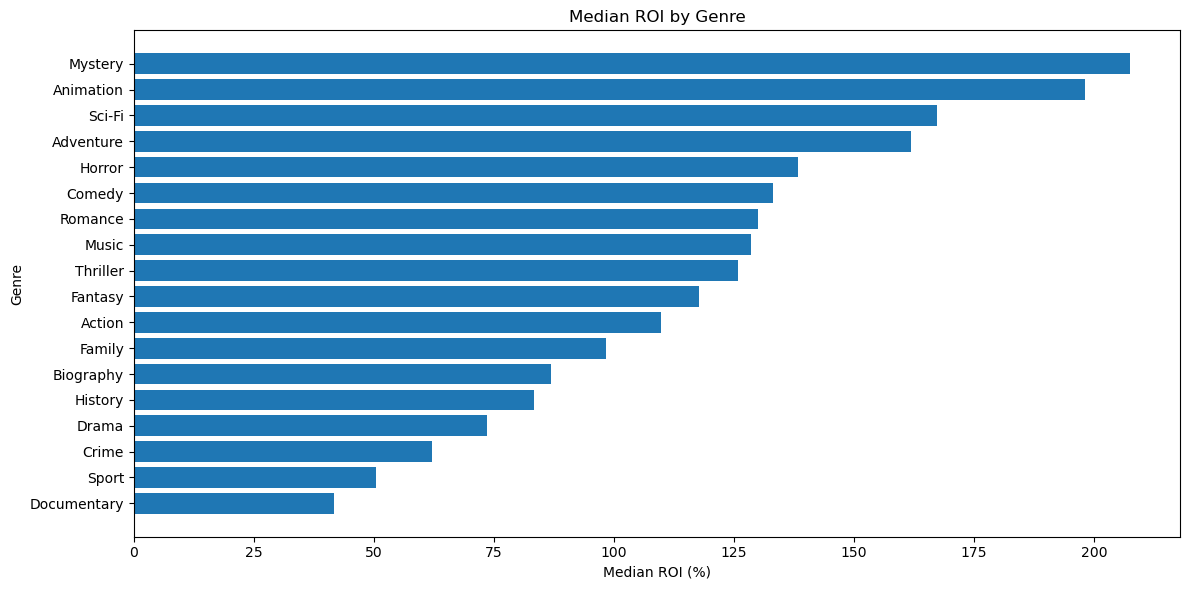

In [ ]:
#9. Visualize the results using a bar chart.
# First we visualize the median ROI by genre
ROI_plot = filtered_genres.sort_values("median_ROI")
plt.figure(figsize=(12,6))

plt.barh(ROI_plot.index, ROI_plot["median_ROI"])
plt.xlabel("Median ROI (%)")
plt.ylabel("Genre")
plt.title("Median ROI by Genre")

plt.tight_layout()
plt.show()

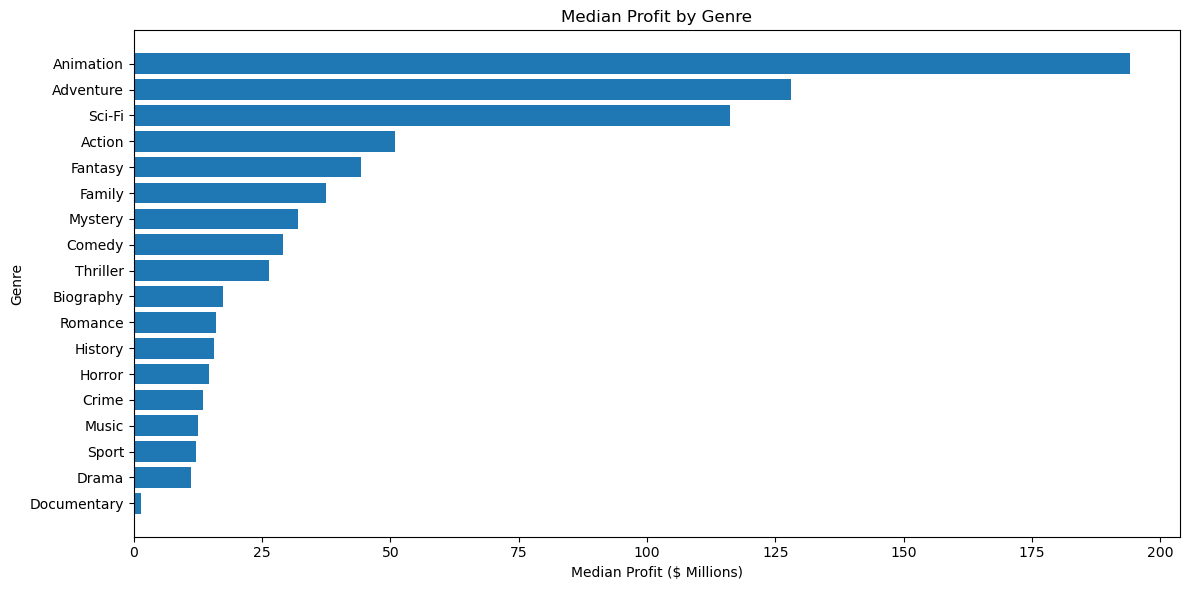

In [ ]:
# Visualize the median profit by genre
profit_plot = filtered_genres.sort_values("median_profit")

profit_plot["median_profit_millions"] = (
    profit_plot["median_profit"] / 1_000_000
)

profit_plot = profit_plot.sort_values("median_profit_millions")
plt.figure(figsize=(12,6))

plt.barh(profit_plot.index, profit_plot["median_profit_millions"])
plt.xlabel("Median Profit ($ Millions)")
plt.ylabel("Genre")
plt.title("Median Profit by Genre")

plt.tight_layout()
plt.show()

**Based on the visualizations, the following are the best recommendations;**

**1. Prioritize Animation, Adventure and Sci-Fi**

These three genres perform strongly on both profitability and ROI:

Animation – highest median profit ($194M) and very high ROI (198%).

Adventure – second-highest median profit ($128M) and strong ROI (162%).

Sci-Fi – third-highest median profit ($116M) and ROI (168%).

Recommendation: These should be the primary genres for investment because they combine strong returns with high absolute profits.

**2. Consider Mystery for high-return, lower-risk investments**

Mystery has the highest median ROI (~208%), meaning it generates the strongest return relative to the amount invested. However, its median profit (~$32M) is much lower than Animation, Adventure and Sci-Fi.

Recommendation: Invest in Mystery when the goal is capital efficiency/ROI, rather than maximizing total dollar profit.

**3. Be very careful when investing in Drama, Sport and Documentary**

These genres appear at the bottom of the profitability chart:

Documentary – extremely low median profit and ROI.

Drama – low median profit and relatively low ROI.

Sport – low median profit and ROI.

Recommendation: Avoid large investments in these genres unless there are specific factors such as a strong franchise, famous cast, low production budget, or clear target audience that justify the investment.

**EDA Summary**


**1. I first examined the structure of the dataset**

Checked the columns, data types, number of records, and missing values.
Identified the important variables for analyzing movie performance, such as genre, budget, revenue, profit, ROI, and movie count.

**2. I analyzed movie profitability**

Calculated profit to determine how much money movies made after accounting for their budget.
I also calculated ROI (Return on Investment) to measure how efficiently the budget was converted into revenue/profit.

**3. I grouped movies by genre**

I used groupby("genre") to compare genres.

**4. I calculated:**

Median ROI
Median profit
Movie count
I used the median because movie profits and ROI can be heavily affected by a few extremely successful blockbuster movies. Median gives us a better picture of the typical movie in each genre.

**5. I visualized genre performance**

I created charts comparing median profit by genre. The visualization helped us see which genres generally perform better financially.


**Recommendation**

The studio should prioritize genres that consistently demonstrate strong median profit and ROI, while considering the number of movies available for each genre. Investment decisions should be based on both profitability and efficiency rather than revenue alone, with lower-performing genres receiving more cautious or smaller-budget investments.

# SYLVAN 